In [1]:
## %pip install qiskit-aer qiskit-algorithms qiskit-ibm-runtime qiskit-nature pyscf networkx

# VQE for $H_2$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import qiskit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# Qiskit Nature (electronic structure -> qubit Hamiltonian)
import qiskit_nature
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

# PySCF (classical electronic structure backend)
import pyscf


In [3]:
# build the H2 electronic structure problem at equilibrium

# H2 equilibrium bond length
bond_length = 0.735  # Angstrom 

driver = PySCFDriver(
    atom=f"H 0.0 0.0 0.0; H 0.0 0.0 {bond_length}",
    basis="sto-3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

problem = driver.run()

print(f"Number of spatial orbitals : {problem.num_spatial_orbitals}")
print(f"Number of spin orbitals    : {2 * problem.num_spatial_orbitals}")
print(f"Number of particles        : {problem.num_particles}")
print(f"Nuclear repulsion energy   : {problem.nuclear_repulsion_energy:.6f} Hartree")
print(f"Reference HF energy        : {problem.reference_energy:.6f} Hartree")

Number of spatial orbitals : 2
Number of spin orbitals    : 4
Number of particles        : (1, 1)
Nuclear repulsion energy   : 0.719969 Hartree
Reference HF energy        : -1.116999 Hartree


In [4]:
"""
H2 at equilibrium (Kandala et al. Nature 549, 242-246, 2017):
- 2 H atoms, each contributes 1s orbital → 4 spin orbitals total
- No core orbitals to freeze (Period I element)
- Paper uses binary tree encoding; here we use parity mapping 
- Parity mapping + tapering → 2 qubits, 5 Pauli terms (paper: 4, difference is II constant term)
- FCI total energy matches paper: ~-1.137 Hartree
"""

# H2 uses full space
problem = driver.run()

print(f"Hamiltonian constants : {problem.hamiltonian.constants}")
print(f"Num spatial orbitals  : {problem.num_spatial_orbitals}")
print(f"Num particles         : {problem.num_particles}")

Hamiltonian constants : {'nuclear_repulsion_energy': np.float64(0.7199689944489797)}
Num spatial orbitals  : 2
Num particles         : (1, 1)


In [5]:
# map fermionic Hamiltonian to qubit Hamiltonian
mapper = ParityMapper(num_particles=problem.num_particles)      # parity mapping 
qubit_hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"Number of qubits      : {qubit_hamiltonian.num_qubits}")
print(f"Number of Pauli terms : {len(qubit_hamiltonian)}")

print(f"\nAll Pauli terms:")
for pauli, coeff in qubit_hamiltonian.to_list():
    print(f"  {pauli} : {coeff.real:+.6f}")

# FCI reference -> diagonalize the 2-qubit Hamiltonian directly
H_matrix = qubit_hamiltonian.to_matrix()
fci_electronic = float(np.linalg.eigvalsh(H_matrix)[0])
print(f"\nFCI electronic energy : {fci_electronic:.6f} Hartree")

fci_total = fci_electronic + problem.nuclear_repulsion_energy
print(f"FCI total energy      : {fci_total:.6f} Hartree")
print(f"Expected (paper)      : ~-1.137 Hartree @ R = 0.735 Å")

Number of qubits      : 2
Number of Pauli terms : 5

All Pauli terms:
  II : -1.052373
  IZ : +0.397937
  ZI : -0.397937
  ZZ : -0.011280
  XX : +0.180931

FCI electronic energy : -1.857275 Hartree
FCI total energy      : -1.137306 Hartree
Expected (paper)      : ~-1.137 Hartree @ R = 0.735 Å


In [6]:
# # UCCSD ansatz with Hartree-Fock initial state

# # Hartree-Fock state --> the classical mean-field reference
# hf_state = HartreeFock(
#     num_spatial_orbitals=problem.num_spatial_orbitals,
#     num_particles=problem.num_particles,
#     qubit_mapper=mapper,
# )

# # UCCSD ansatz 
# ansatz = UCCSD(
#     num_spatial_orbitals=problem.num_spatial_orbitals,
#     num_particles=problem.num_particles,
#     qubit_mapper=mapper,
#     initial_state=hf_state,
# )

# print(f"Number of qubits      : {ansatz.num_qubits}")
# print(f"Number of parameters  : {ansatz.num_parameters}")
# print(f"Circuit depth         : {ansatz.decompose().depth()}")

In [7]:
# HEA ansatz for H2 (2 qubits)
# Paper uses d=1, linear entanglement for 2-qubit system
from qiskit.circuit.library import efficient_su2



ansatz = efficient_su2(
    num_qubits=2,
    reps=1,
    entanglement=[[0,1]],           
    su2_gates=["rz", "ry"],
)

print(f"Number of qubits     : {ansatz.num_qubits}")
print(f"Number of parameters : {ansatz.num_parameters}")  
print(f"Circuit depth        : {ansatz.decompose().depth()}")

Number of qubits     : 2
Number of parameters : 8
Circuit depth        : 5


In [ ]:
# Noiseless VQE benchmark using HEA ansatz with L-BFGS-B optimizer to verify ansatz expressibility against FCI
estimator = StatevectorEstimator()

history = {"iter": 0, "energies": []}

def cost_function(params):
    """Compute <psi(params) | H | psi(params)>"""
    job = estimator.run([(ansatz, qubit_hamiltonian, [params])])
    energy = float(np.asarray(job.result()[0].data.evs).reshape(-1)[0])
    history["iter"] += 1
    history["energies"].append(energy)
    return energy

rng = np.random.default_rng(42)
x0 = rng.uniform(-np.pi, np.pi, ansatz.num_parameters)
initial_energy = cost_function(x0)
print(f"Initial energy (random init) : {initial_energy:.6f} Hartree")

history = {"iter": 0, "energies": []}

print("\nRunning VQE (HEA + L-BFGS-B, noiseless)...")
result = minimize(
    cost_function,
    x0=x0,
    method="L-BFGS-B",
    options={"maxiter": 200, "ftol": 1e-12, "gtol": 1e-8},
)

vqe_energy_electronic = float(result.fun)
n_evals = history["iter"]

error_mHa = (vqe_energy_electronic - fci_electronic) * 1000
print(f"\nVQE electronic energy : {vqe_energy_electronic:.6f} Hartree")
print(f"FCI electronic energy : {fci_electronic:.6f} Hartree")
print(f"VQE total energy      : {vqe_energy_electronic + problem.nuclear_repulsion_energy:.6f} Hartree")
print(f"FCI total energy      : {fci_total:.6f} Hartree")
print(f"Error                 : {error_mHa:+.4f} mHartree")
print(f"Chemical accuracy     : {'YES' if abs(error_mHa) < 1.6 else 'NO'} (threshold 1.6 mHa)")
print(f"Function evaluations  : {n_evals}")

plt.figure(figsize=(8, 4.5))
plt.plot(history["energies"], lw=1.5, marker="o", ms=4, label="HEA-VQE")
plt.axhline(fci_electronic, color="r", ls="--", lw=1, label=f"FCI = {fci_electronic:.4f}")
plt.axhline(initial_energy, color="gray", ls=":", lw=1, label=f"Initial = {initial_energy:.4f}")
plt.xlabel("Cost-function evaluations")
plt.ylabel("Electronic energy (Hartree)")
plt.title(f"VQE convergence — H2 @ R = {bond_length} Å (HEA, 2 qubits)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Noiseless VQE benchmark using HEA ansatz with SPSA optimizer to validate optimizer behavior in noise-free conditions
from qiskit_algorithms.optimizers import SPSA

"""
Noiseless should use L-BFGS-B.
SPSA is designed for noisy environments (only needs 2 energy measurements per iteration).
Here shown for comparison — performance is worse than L-BFGS-B in noiseless setting.
"""

estimator = StatevectorEstimator()

history = {"iter": 0, "energies": []}

def cost_function(params):
    """Compute <psi(params) | H | psi(params)>"""
    job = estimator.run([(ansatz, qubit_hamiltonian, [params])])
    energy = float(np.asarray(job.result()[0].data.evs).reshape(-1)[0])
    history["iter"] += 1
    history["energies"].append(energy)
    return energy

rng = np.random.default_rng(42)
x0_spsa = rng.uniform(-np.pi, np.pi, ansatz.num_parameters)
initial_energy_spsa = cost_function(x0_spsa)
print(f"Initial energy (random init) : {initial_energy_spsa:.6f} Hartree")

history = {"iter": 0, "energies": []}

print("\nRunning VQE (HEA + SPSA, noiseless)...")

spsa= SPSA(
    maxiter=250,
    blocking=False,
    trust_region=False,
    learning_rate=None,
    perturbation=None,
    last_avg=25,
    resamplings=1,
)

result = spsa.minimize(cost_function, x0=x0_spsa)

vqe_energy_electronic = float(result.fun)
n_evals = history["iter"]

error_mHa = (vqe_energy_electronic - fci_electronic) * 1000
print(f"\nVQE electronic energy : {vqe_energy_electronic:.6f} Hartree")
print(f"FCI electronic energy : {fci_electronic:.6f} Hartree")
print(f"Error                 : {error_mHa:+.4f} mHartree")
print(f"Chemical accuracy     : {'YES' if abs(error_mHa) < 1.6 else 'NO'} (threshold 1.6 mHa)")
print(f"Function evaluations  : {n_evals}")

plt.figure(figsize=(8, 4.5))
plt.plot(history["energies"], lw=1.5, marker="o", ms=4, label="HEA-VQE (SPSA)")
plt.axhline(fci_electronic, color="r", ls="--", lw=1, label=f"FCI = {fci_electronic:.4f}")
plt.axhline(initial_energy_spsa, color="gray", ls=":", lw=1, label=f"Initial = {initial_energy_spsa:.4f}")
plt.xlabel("Cost-function evaluations")
plt.ylabel("Electronic energy (Hartree)")
plt.title(f"VQE convergence — H2 @ R = {bond_length} Å (HEA + SPSA, noiseless)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

R=0.300  L-BFGS-B=-0.6018  SPSA=-0.5941  FCI=-0.6018
R=0.400  L-BFGS-B=-0.9141  SPSA=-0.9139  FCI=-0.9141
R=0.500  L-BFGS-B=-1.0552  SPSA=-1.0546  FCI=-1.0552
R=0.600  L-BFGS-B=-1.1163  SPSA=-1.1163  FCI=-1.1163
R=0.700  L-BFGS-B=-1.1362  SPSA=-1.1356  FCI=-1.1362
R=0.735  L-BFGS-B=-1.1373  SPSA=-1.1373  FCI=-1.1373
R=0.800  L-BFGS-B=-1.1341  SPSA=-1.1340  FCI=-1.1341
R=0.900  L-BFGS-B=-1.1206  SPSA=-1.1169  FCI=-1.1206
R=1.000  L-BFGS-B=-1.1012  SPSA=-1.1011  FCI=-1.1012
R=1.100  L-BFGS-B=-1.0792  SPSA=-1.0785  FCI=-1.0792
R=1.200  L-BFGS-B=-1.0567  SPSA=-1.0544  FCI=-1.0567
R=1.300  L-BFGS-B=-1.0352  SPSA=-1.0326  FCI=-1.0352
R=1.400  L-BFGS-B=-1.0155  SPSA=-1.0104  FCI=-1.0155
R=1.500  L-BFGS-B=-0.9981  SPSA=-0.9936  FCI=-0.9981
R=1.600  L-BFGS-B=-0.9835  SPSA=-0.9790  FCI=-0.9835
R=1.700  L-BFGS-B=-0.9714  SPSA=-0.9679  FCI=-0.9714
R=1.800  L-BFGS-B=-0.9618  SPSA=-0.9379  FCI=-0.9618
R=2.000  L-BFGS-B=-0.9486  SPSA=-0.9446  FCI=-0.9486
R=2.200  L-BFGS-B=-0.9412  SPSA=-0.9376  FCI=-

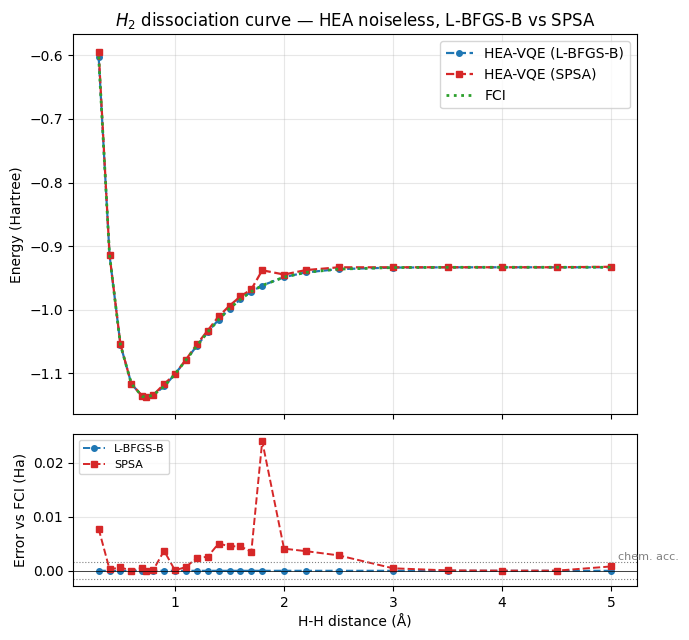

In [10]:
# scan bond length and plot PEC (HEA, noiseless using L-BFGS-B and SPSA)

def run_vqe_at_distance(R, optimizer="lbfgsb"):
    """
    Full HEA-VQE pipeline at one H-H distance.
    optimizer: "lbfgsb" or "spsa"
    Returns: (initial_total, VQE_total, FCI_total) in Hartree.
    """
    drv = PySCFDriver(
        atom=f"H 0.0 0.0 0.0; H 0.0 0.0 {R}",
        basis="sto-3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM,
    )

    prob = drv.run()  # H2: no active space transformer needed

    mp = ParityMapper(num_particles=prob.num_particles)
    H = mp.map(prob.hamiltonian.second_q_op())
    shift = prob.nuclear_repulsion_energy
    fci_elec = float(np.linalg.eigvalsh(H.to_matrix())[0])

    ans = efficient_su2(
        num_qubits=2, reps=1,       
        entanglement=[[0,1]],
        su2_gates=["rz", "ry"],
    )
    est = StatevectorEstimator()

    def cost(p):
        return float(np.asarray(est.run([(ans, H, [p])]).result()[0].data.evs).reshape(-1)[0])

    rng = np.random.default_rng(42)
    initial_elec = cost(rng.uniform(-np.pi, np.pi, ans.num_parameters))

    if optimizer == "lbfgsb":
        best_energy = np.inf
        for _ in range(3):
            x0 = rng.uniform(-np.pi, np.pi, ans.num_parameters)
            res = minimize(
                cost, x0=x0,
                method="L-BFGS-B",
                options={"maxiter": 200, "ftol": 1e-12, "gtol": 1e-8},
            )
            if res.fun < best_energy:
                best_energy = res.fun
    else:
        x0 = rng.uniform(-np.pi, np.pi, ans.num_parameters)
        res = spsa.minimize(cost, x0=x0)
        best_energy = float(res.fun)

    return initial_elec + shift, best_energy + shift, fci_elec + shift


distances = np.array([
    0.3, 0.4, 0.5, 0.6, 0.7, 0.735,
    0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4,
    1.5, 1.6, 1.7, 1.8, 2.0, 2.2,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0
])

E_initial, E_vqe_lbfgs, E_vqe_spsa, E_fci = [], [], [], []
for R in distances:
    initial, vqe_l, fci = run_vqe_at_distance(float(R), optimizer="lbfgsb")
    _,       vqe_s, _   = run_vqe_at_distance(float(R), optimizer="spsa")
    E_initial.append(initial)
    E_vqe_lbfgs.append(vqe_l)
    E_vqe_spsa.append(vqe_s)
    E_fci.append(fci)
    print(f"R={R:.3f}  L-BFGS-B={vqe_l:.4f}  SPSA={vqe_s:.4f}  FCI={fci:.4f}")

E_initial, E_vqe_lbfgs, E_vqe_spsa, E_fci = map(np.array, (E_initial, E_vqe_lbfgs, E_vqe_spsa, E_fci))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.2]})

ax1.plot(distances, E_vqe_lbfgs, "o--", color="#1f77b4", lw=1.6, ms=4, label="HEA-VQE (L-BFGS-B)")
ax1.plot(distances, E_vqe_spsa,  "s--", color="#d62728", lw=1.6, ms=4, label="HEA-VQE (SPSA)")
ax1.plot(distances, E_fci,       ":",   color="#2ca02c", lw=2.0, label="FCI")
ax1.set_ylabel("Energy (Hartree)")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)
ax1.set_title("$H_2$ dissociation curve — HEA noiseless, L-BFGS-B vs SPSA")

ax2.plot(distances, E_vqe_lbfgs - E_fci, "o--", color="#1f77b4", lw=1.4, ms=4, label="L-BFGS-B")
ax2.plot(distances, E_vqe_spsa  - E_fci, "s--", color="#d62728", lw=1.4, ms=4, label="SPSA")
ax2.axhline(0, color="k", lw=0.5)
ax2.axhline( 1.6e-3, color="gray", ls=":", lw=0.8)
ax2.axhline(-1.6e-3, color="gray", ls=":", lw=0.8)
ax2.text(distances[-1], 1.6e-3, "  chem. acc.", fontsize=8, color="gray", va="bottom")
ax2.set_xlabel("H-H distance (Å)")
ax2.set_ylabel("Error vs FCI (Ha)")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## logical circuit
ansatz.decompose().draw("mpl", style="clifford")


In [ ]:
# plot transpiled circuit for H2 (2 qubits)
from qiskit import transpile
from qiskit.transpiler import CouplingMap


# H2 only needs 2 qubits, use simple linear coupling map
h2_coupling = CouplingMap([
    [2,3],[3,2],
])

ansatz_transpiled = transpile(
    ansatz,
    coupling_map=h2_coupling,
    basis_gates=["rz", "rx", "ry", "cz"],
    optimization_level=3,
    seed_transpiler=42,
)

print(f"Depth  : {ansatz_transpiled.depth()}")
print(f"CZ     : {ansatz_transpiled.count_ops().get('cz', 0)}")
print(f"All ops: {ansatz_transpiled.count_ops()}")

ansatz_transpiled.draw("mpl", style="clifford")

# Noise from real backend(FakeFez)

### Choose topological structure on FakeBackend (ibm_fez)

In [27]:
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit import transpile
from qiskit.transpiler import CouplingMap

fake_backend = FakeFez()

noise_model_fez_full = NoiseModel.from_backend(fake_backend)
noise_model_fez = NoiseModel(basis_gates=noise_model_fez_full.basis_gates)

# copy only q2, q3 related errors
if hasattr(noise_model_fez_full, '_local_quantum_errors'):
    for gate, qubit_dict in noise_model_fez_full._local_quantum_errors.items():
        for qubits, error in qubit_dict.items():
            if all(q in [2, 3] for q in qubits):
                noise_model_fez.add_quantum_error(error, gate, list(qubits))

coupling_map_fez = CouplingMap([[2,3],[3,2]])
basis_gates_fez = noise_model_fez_full.basis_gates

initial_layout = {
    ansatz.qregs[0][0]: 2,
    ansatz.qregs[0][1]: 3,
}

ansatz_fez = transpile(
    ansatz,
    backend=fake_backend,
    optimization_level=3,
    initial_layout=initial_layout,
    seed_transpiler=42,
)

ops = ansatz_fez.count_ops()
print(f"Depth  : {ansatz_fez.depth()}")
print(f"CZ     : {ops.get('cz', 0)}")
print(f"All ops: {ops}")
print(f"Layout : {ansatz_fez.layout.final_index_layout()}")

Depth  : 14
CZ     : 1
All ops: OrderedDict([('rz', 14), ('sx', 9), ('cz', 1)])
Layout : [2, 3]


In [ ]:
# calculate fixed distance VQE of HEA with SPSA using FakeFez backend (H2)
qubit_ham_fez = qubit_hamiltonian.apply_layout(ansatz_fez.layout)

noisy_estimator_fez = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model_fez,
            "coupling_map": list(coupling_map_fez.get_edges()),
            "basis_gates": basis_gates_fez,
        },
        "run_options": {"shots": 512, "seed": None},
    }
)

history_fez = {"iter": 0, "energies": []}

def cost_function_fez(params):
    pub = (ansatz_fez, [qubit_ham_fez], [params])
    result = noisy_estimator_fez.run(pubs=[pub]).result()
    energy = float(result[0].data.evs[0])
    history_fez["iter"] += 1
    history_fez["energies"].append(energy)
    if history_fez["iter"] % 5 == 0:
        print(f"  iter {history_fez['iter']:3d}: E = {energy:.6f} Ha")
    return energy

rng = np.random.default_rng(42)
x0 = rng.uniform(-np.pi, np.pi, ansatz_fez.num_parameters)

result_fez = spsa.minimize(cost_function_fez, x0=x0)

total_fez = result_fez.fun + problem.nuclear_repulsion_energy
print(f"\nFakeFez noisy VQE : {total_fez:.6f} Ha")
print(f"FCI total         : {fci_total:.6f} Ha")
print(f"Error             : {(result_fez.fun - fci_electronic)*1000:+.4f} mHa")

In [26]:
# check FakeFez actual noise parameters (q2, q3 only)
props = fake_backend.properties()

print("Single-qubit gate errors (q2, q3):")
for gate in ["sx", "x"]:
    for qubit in [2, 3]:
        try:
            err = props.gate_error(gate, [qubit])
            print(f"  {gate} q{qubit}: {err:.2e}")
        except:
            pass

print("\nTwo-qubit gate errors (q2-q3):")
for pair in [(2,3),(3,2)]:
    try:
        err = props.gate_error("cz", list(pair))
        print(f"  cz {pair}: {err:.2e}")
    except Exception as e:
        print(f"  cz {pair}: {e}")

print("\nT1, T2 (q2, q3):")
for qubit in [2, 3]:
    try:
        t1 = props.t1(qubit)
        t2 = props.t2(qubit)
        print(f"  q{qubit}: T1={t1*1e6:.1f}μs, T2={t2*1e6:.1f}μs")
    except:
        pass

Single-qubit gate errors (q2, q3):
  sx q2: 1.98e-04
  sx q3: 2.39e-04
  x q2: 1.98e-04
  x q3: 2.39e-04

Two-qubit gate errors (q2-q3):
  cz (2, 3): 2.98e-03
  cz (3, 2): 2.98e-03

T1, T2 (q2, q3):
  q2: T1=274.4μs, T2=100.0μs
  q3: T1=219.7μs, T2=215.5μs


# Build coupling map and noise model for topology of real device 

In [16]:
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error
from qiskit_aer import AerSimulator
from qiskit import transpile
import qiskit_aer.noise as noise
from qiskit.transpiler import CouplingMap


# Noise model user-defined parameters 
p1 = 1e-3     # single-qubit depolarizing error 
p2 = 5e-3     # two-qubit depolarizing error 
t1 = 75e-6    # T1 relaxation time, typical 50-100 μs
t2 = 50e-6    # T2 dephasing time, typical 30-80 μs
gate_time_1q = 30e-9    # 30 ns for rx, ry, rz 
gate_time_2q = 150e-9   # 150 ns for CPhase/CZ 

err1_dep = noise.depolarizing_error(p1, 1)
err2_dep = noise.depolarizing_error(p2, 2)

err1_thermal = thermal_relaxation_error(t1, t2, gate_time_1q)
err2_thermal = thermal_relaxation_error(t1, t2, gate_time_2q).expand(
    thermal_relaxation_error(t1, t2, gate_time_2q)
)

err1_combined = err1_dep.compose(err1_thermal)
err2_combined = err2_dep.compose(err2_thermal)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(err1_combined, ["rx", "ry", "rz"])
noise_model.add_all_qubit_quantum_error(err2_combined, ["cz"])

cross_sim = AerSimulator(
    noise_model=noise_model,
    coupling_map=h2_coupling,
    basis_gates=["rz", "rx", "ry", "cz"],
)

ansatz_cross = transpile(
    ansatz,
    coupling_map=h2_coupling,
    basis_gates=["rz", "rx", "ry", "cz"],
    optimization_level=3,
    seed_transpiler=42,
    initial_layout={
        ansatz.qregs[0][0]: 2,   
        ansatz.qregs[0][1]: 3,   
    },
)

print(f"Depth : {ansatz_cross.depth()}")
print(f"CZ    : {ansatz_cross.count_ops().get('cz', 0)}")
print(f"Layout: {ansatz_cross.layout.final_index_layout()}")
print(f"\nNoise parameters  :")
print(f"  p1 (single-qubit) : {p1:.1e}")
print(f"  p2 (two-qubit)    : {p2:.1e}")
print(f"  T1                : {t1*1e6:.0f} μs")
print(f"  T2                : {t2*1e6:.0f} μs")
print(f"  gate_time_1q      : {gate_time_1q*1e9:.0f} ns")
print(f"  gate_time_2q      : {gate_time_2q*1e9:.0f} ns")

Depth : 9
CZ    : 1
Layout: [2, 3]

Noise parameters  :
  p1 (single-qubit) : 1.0e-03
  p2 (two-qubit)    : 5.0e-03
  T1                : 75 μs
  T2                : 50 μs
  gate_time_1q      : 30 ns
  gate_time_2q      : 150 ns


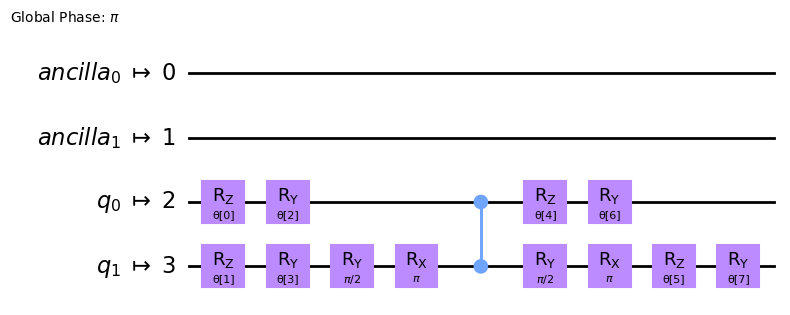

In [28]:
ansatz_cross.draw("mpl", style = "clifford")

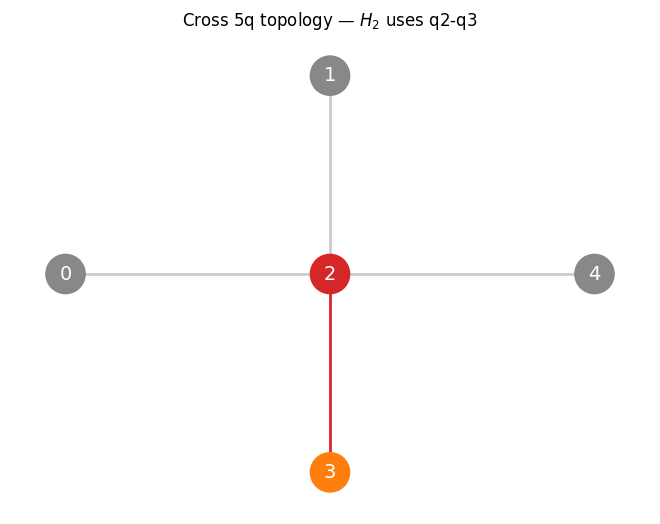

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

# Cross 5-qubit coupling map (center = qubit 2) 
cross_5q = CouplingMap([
    [0,2],[2,0],
    [1,2],[2,1],
    [3,2],[2,3],
    [4,2],[2,4],
])

G = nx.Graph()
G.add_edges_from(cross_5q.get_edges())

# cross 5q topology positions
pos = {0: (-1, 0), 1: (0, 1), 2: (0, 0), 3: (0, -1), 4: (1, 0)}

# color: red = center (q2), orange = H2 used (q0), green = unused
colors = []
for n in G.nodes():
    if n == 2:
        colors.append("#D62728")   # center q2 
    elif n == 3:
        colors.append("#FF7F0E")   # q3 
    else:
        colors.append("#888888")   # unused

# edge color: highlight q2-q3 connection
edge_colors = []
for e in G.edges():
    if set(e) == {2, 3}:
        edge_colors.append("#D62728")
    else:
        edge_colors.append("#CCCCCC")

nx.draw(G, pos=pos, with_labels=True,
        node_color=colors,
        edge_color=edge_colors,
        node_size=800, font_color="white", font_size=14,
        width=2)

plt.title("Cross 5q topology — $H_2$ uses q2-q3")
plt.show()

In [ ]:
# calculate fixed distance VQE of HEA with SPSA using cross 5q topology (H2)
qubit_ham_cross = qubit_hamiltonian.apply_layout(ansatz_cross.layout)

noisy_estimator_cross = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": list(h2_coupling.get_edges()),  
            "basis_gates": ["rz", "ry", "rx", "cz"],
        },
        "run_options": {"shots": 512, "seed": None},
    }
)

history_cross = {"iter": 0, "energies": []}

def cost_function_cross(params):
    pub = (ansatz_cross, [qubit_ham_cross], [params])
    result = noisy_estimator_cross.run(pubs=[pub]).result()
    energy = float(result[0].data.evs[0])
    history_cross["iter"] += 1
    history_cross["energies"].append(energy)
    if history_cross["iter"] % 5 == 0:
        print(f"  iter {history_cross['iter']:3d}: E = {energy:.6f} Ha")
    return energy

rng = np.random.default_rng(42)
x0 = rng.uniform(-np.pi, np.pi, ansatz_cross.num_parameters)

result_cross = spsa.minimize(cost_function_cross, x0=x0)

total_cross = result_cross.fun + problem.nuclear_repulsion_energy
print(f"\nCross topology noisy VQE : {total_cross:.6f} Ha")
print(f"FCI total                : {fci_total:.6f} Ha")
print(f"Error                    : {(result_cross.fun - fci_electronic)*1000:+.4f} mHa")

In [20]:
def run_vqe_noisy_at_distance(R, backend_type="fakefez", optimizer="spsa", n_runs=1):
    """
    backend_type: "fakefez" or "cross"
    optimizer: "spsa" or "lbfgsb"
    n_runs: number of independent runs to average (paper uses 100)
    """
    drv = PySCFDriver(
        atom=f"H 0.0 0.0 0.0; H 0.0 0.0 {R}",
        basis="sto-3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM,
    )

    prob = drv.run()

    mp = ParityMapper(num_particles=prob.num_particles)
    H = mp.map(prob.hamiltonian.second_q_op())

    shift = prob.nuclear_repulsion_energy
    fci_elec = float(np.linalg.eigvalsh(H.to_matrix())[0])

    ans = efficient_su2(
        num_qubits=2, reps=1,
        entanglement=[[0,1]],
        su2_gates=["rz", "ry"],
    )

    if backend_type == "fakefez":
        ans_t = transpile(
            ans, backend=fake_backend, optimization_level=3,
            initial_layout={ans.qregs[0][0]: 2, ans.qregs[0][1]: 3},
            seed_transpiler=42,
        )
        H_t = H.apply_layout(ans_t.layout)
        est = AerEstimator(options={
            "backend_options": {
                "noise_model": noise_model_fez,
                "coupling_map": list(coupling_map_fez.get_edges()),
                "basis_gates": basis_gates_fez,
            },
            "run_options": {"shots": 512, "seed": None},
        })
    else:
        ans_t = transpile(
            ans, coupling_map=h2_coupling,
            basis_gates=["rz", "rx", "ry", "cz"],
            optimization_level=3, seed_transpiler=42,
            initial_layout={ans.qregs[0][0]: 2, ans.qregs[0][1]: 3},
        )
        H_t = H.apply_layout(ans_t.layout)
        est = AerEstimator(options={
            "backend_options": {
                "noise_model": noise_model,
                "coupling_map": list(h2_coupling.get_edges()),
                "basis_gates": ["rz", "rx", "ry", "cz"],
            },
            "run_options": {"shots": 512, "seed": None},
        })

    def cost(p):
        pub = (ans_t, [H_t], [p])
        return float(est.run(pubs=[pub]).result()[0].data.evs[0])

    initial_elec = cost(np.zeros(ans_t.num_parameters))

    # n_runs independent optimizations, take mean 
    all_energies = []
    for i in range(n_runs):
        rng = np.random.default_rng(i)  # seed different for each run
        if optimizer == "spsa":
            x0 = rng.uniform(-np.pi, np.pi, ans_t.num_parameters)
            res = spsa.minimize(cost, x0=x0)
            all_energies.append(float(res.fun))
        else:
            best_energy = np.inf
            for _ in range(3):
                x0 = rng.uniform(-np.pi, np.pi, ans_t.num_parameters)
                res = minimize(cost, x0=x0, method="L-BFGS-B",
                              options={"maxiter": 200, "ftol": 1e-12, "gtol": 1e-8})
                if res.fun < best_energy:
                    best_energy = res.fun
            all_energies.append(best_energy)

    vqe_elec = np.mean(all_energies)

    return initial_elec + shift, vqe_elec + shift, fci_elec + shift, n_runs

R=0.300  FakeFez(SPSA)=-0.5901  FakeFez(L-BFGS-B)=-0.5936  Cross(SPSA)=-0.5583  Cross(L-BFGS-B)=-0.5800
R=0.400  FakeFez(SPSA)=-0.9026  FakeFez(L-BFGS-B)=-0.9071  Cross(SPSA)=-0.8882  Cross(L-BFGS-B)=-0.8954
R=0.500  FakeFez(SPSA)=-1.0442  FakeFez(L-BFGS-B)=-1.0491  Cross(SPSA)=-1.0317  Cross(L-BFGS-B)=-1.0391
R=0.600  FakeFez(SPSA)=-1.1060  FakeFez(L-BFGS-B)=-1.1111  Cross(SPSA)=-1.0948  Cross(L-BFGS-B)=-1.1024
R=0.700  FakeFez(SPSA)=-1.1266  FakeFez(L-BFGS-B)=-1.1317  Cross(SPSA)=-1.1177  Cross(L-BFGS-B)=-1.1241
R=0.735  FakeFez(SPSA)=-1.1293  FakeFez(L-BFGS-B)=-1.1331  Cross(SPSA)=-1.1125  Cross(L-BFGS-B)=-1.1258
R=0.800  FakeFez(SPSA)=-1.1261  FakeFez(L-BFGS-B)=-1.1302  Cross(SPSA)=-1.1128  Cross(L-BFGS-B)=-1.1235
R=0.900  FakeFez(SPSA)=-1.1141  FakeFez(L-BFGS-B)=-1.1171  Cross(SPSA)=-1.1047  Cross(L-BFGS-B)=-1.1111
R=1.000  FakeFez(SPSA)=-1.0948  FakeFez(L-BFGS-B)=-1.0981  Cross(SPSA)=-1.0875  Cross(L-BFGS-B)=-1.0926
R=1.100  FakeFez(SPSA)=-1.0733  FakeFez(L-BFGS-B)=-1.0764  Cross

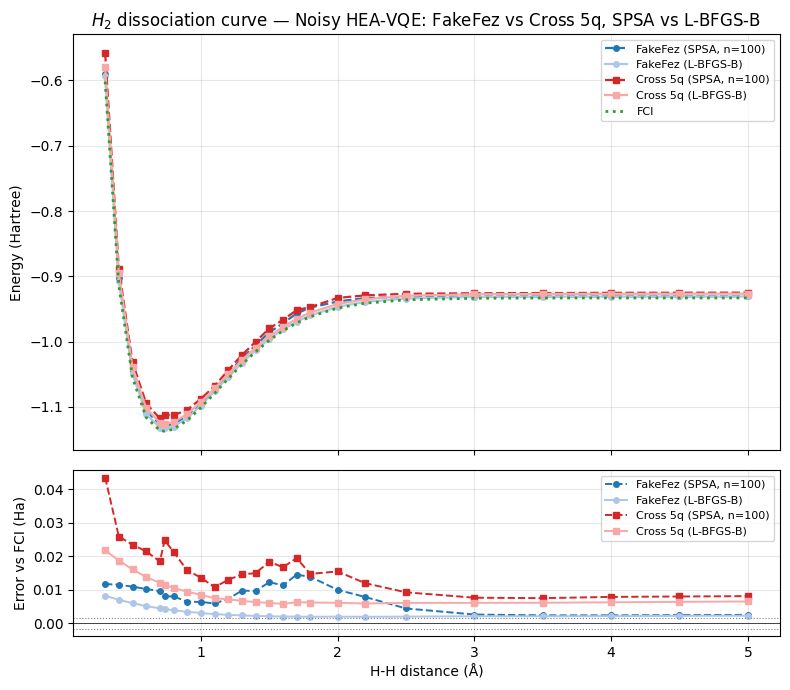

In [32]:
# Noisy VQE PEC scan: FakeFez vs Cross 5q, SPSA vs L-BFGS-B (H2)
E_fez_spsa, E_fez_lbfgs, E_cross_spsa, E_cross_lbfgs, E_fci_n = [], [], [], [], []
n_runs = 100
for R in distances:
    _, vqe_fez_spsa,   fci_f, n_spsa    = run_vqe_noisy_at_distance(float(R), backend_type="fakefez", optimizer="spsa", n_runs= n_runs)
    _, vqe_fez_lbfgs,  _, _             = run_vqe_noisy_at_distance(float(R), backend_type="fakefez", optimizer="lbfgsb")
    _, vqe_cross_spsa, _, _             = run_vqe_noisy_at_distance(float(R), backend_type="cross",   optimizer="spsa", n_runs=n_runs)
    _, vqe_cross_lbfgs,_, _             = run_vqe_noisy_at_distance(float(R), backend_type="cross",   optimizer="lbfgsb")
    E_fez_spsa.append(vqe_fez_spsa)
    E_fez_lbfgs.append(vqe_fez_lbfgs)
    E_cross_spsa.append(vqe_cross_spsa)
    E_cross_lbfgs.append(vqe_cross_lbfgs)
    E_fci_n.append(fci_f)
    print(f"R={R:.3f}  FakeFez(SPSA)={vqe_fez_spsa:.4f}  FakeFez(L-BFGS-B)={vqe_fez_lbfgs:.4f}  Cross(SPSA)={vqe_cross_spsa:.4f}  Cross(L-BFGS-B)={vqe_cross_lbfgs:.4f}")
E_fez_spsa, E_fez_lbfgs, E_cross_spsa, E_cross_lbfgs, E_fci_n = map(
    np.array, (E_fez_spsa, E_fez_lbfgs, E_cross_spsa, E_cross_lbfgs, E_fci_n)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.2]})

ax1.plot(distances, E_fez_spsa,   "o--", color="#1f77b4", lw=1.6, ms=4, label=f"FakeFez (SPSA, n={n_spsa})")
ax1.plot(distances, E_fez_lbfgs,  "o-",  color="#aec7e8", lw=1.6, ms=4, label="FakeFez (L-BFGS-B)")
ax1.plot(distances, E_cross_spsa, "s--", color="#d62728", lw=1.6, ms=4, label=f"Cross 5q (SPSA, n={n_spsa})")
ax1.plot(distances, E_cross_lbfgs,"s-",  color="#f7a9a8", lw=1.6, ms=4, label="Cross 5q (L-BFGS-B)")
ax1.plot(distances, E_fci_n,      ":",   color="#2ca02c", lw=2.0, label="FCI")
ax1.set_ylabel("Energy (Hartree)")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_title(f"$H_2$ dissociation curve — Noisy HEA-VQE: FakeFez vs Cross 5q, SPSA vs L-BFGS-B")

ax2.plot(distances, E_fez_spsa   - E_fci_n, "o--", color="#1f77b4", lw=1.4, ms=4, label=f"FakeFez (SPSA, n={n_spsa})")
ax2.plot(distances, E_fez_lbfgs  - E_fci_n, "o-",  color="#aec7e8", lw=1.4, ms=4, label="FakeFez (L-BFGS-B)")
ax2.plot(distances, E_cross_spsa - E_fci_n, "s--", color="#d62728", lw=1.4, ms=4, label=f"Cross 5q (SPSA, n={n_spsa})")
ax2.plot(distances, E_cross_lbfgs- E_fci_n, "s-",  color="#f7a9a8", lw=1.4, ms=4, label="Cross 5q (L-BFGS-B)")
ax2.axhline(0, color="k", lw=0.5)
ax2.axhline( 1.6e-3, color="gray", ls=":", lw=0.8)
ax2.axhline(-1.6e-3, color="gray", ls=":", lw=0.8)
ax2.set_xlabel("H-H distance (Å)")
ax2.set_ylabel("Error vs FCI (Ha)")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()